# Messages per User

Visualization of message counts per user (anonymized with hashed identifiers).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

space_fmt = FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))

In [2]:
df = pd.read_csv("../data/messages_per_user.csv")
df = df.sort_values("post_count", ascending=False)
df.head(10)

,hashed_name,hashed_email,post_count
116,cd425bfeb05165cb,1a4610955dd76579,44030
2007,4187ee536441ef5c,282b31fe2cec16fc,28817
152,a70f8afb5f8899db,898187efc071f23b,26271
2832,f0ed6fb06a4e410c,cd0e87f8c5d05016,22906
737,116ccb4422752ea1,610a73d264074f29,20663
2151,0807d7e0f32374d6,1b45c66e1a428f71,18468
1585,55e6971faa6a366b,1a3e71b0611171af,17374
2571,cd36adc7ca7944d1,aaa1d95a2e0ad36e,16239
2249,7ebb1397df099a66,284ea833e8651987,15432
2031,ccf618c3bcb06961,24642c97731a0019,14229


In [3]:
print(f"Total unique users: {len(df):,}")
print(f"Total posts: {df['post_count'].sum():,}")
print(f"Users with name: {df['hashed_name'].notna().sum():,}")
print(f"Users with email: {df['hashed_email'].notna().sum():,}")

Total unique users: 239,011
Total posts: 5,985,471
Users with name: 189,310
Users with email: 238,959


# Top 50 posters

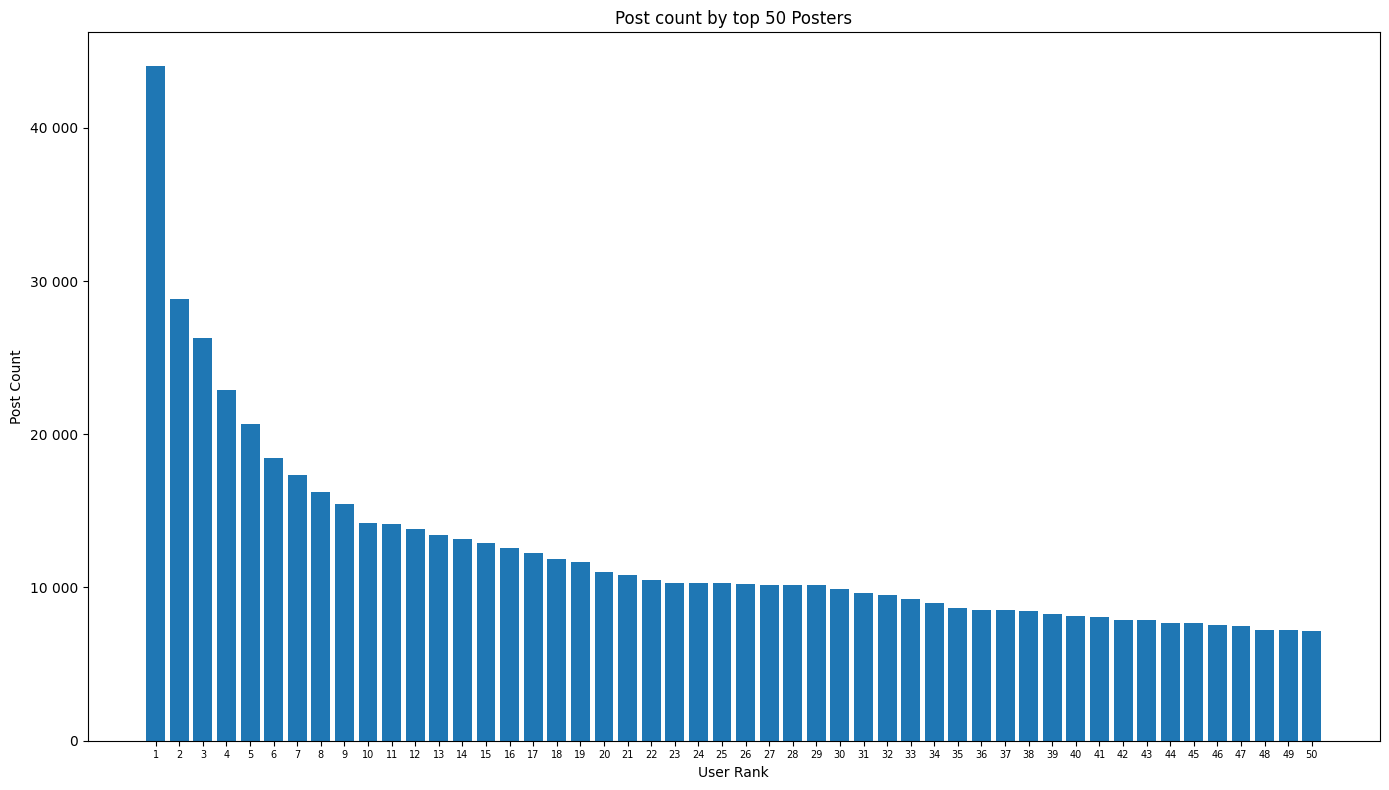

In [4]:
top_50 = df.head(50)

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(range(50), top_50["post_count"])
ax.set_xticks(range(50))
ax.set_xticklabels(range(1, 51), fontsize=7)
ax.yaxis.set_major_formatter(space_fmt)
ax.set_xlabel("User Rank")
ax.set_ylabel("Post Count")
ax.set_title("Post count by top 50 Posters")
plt.tight_layout()
plt.show()

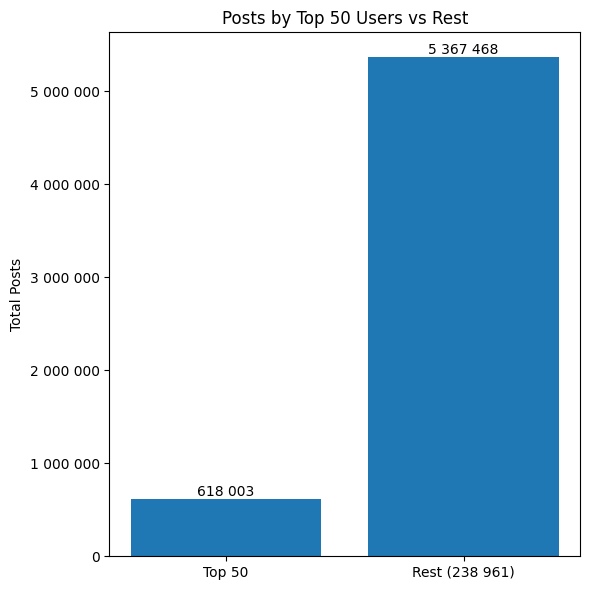

In [5]:
# Top 50 vs rest of users
top_50_sum = df.head(50)["post_count"].sum()
rest_sum = df.iloc[50:]["post_count"].sum()
rest_count = len(df) - 50

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(["Top 50", f"Rest ({rest_count:,})".replace(",", " ")], [top_50_sum, rest_sum])
ax.yaxis.set_major_formatter(space_fmt)
for i, v in enumerate([top_50_sum, rest_sum]):
    ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Total Posts")
ax.set_title("Posts by Top 50 Users vs Rest")
plt.tight_layout()
plt.show()

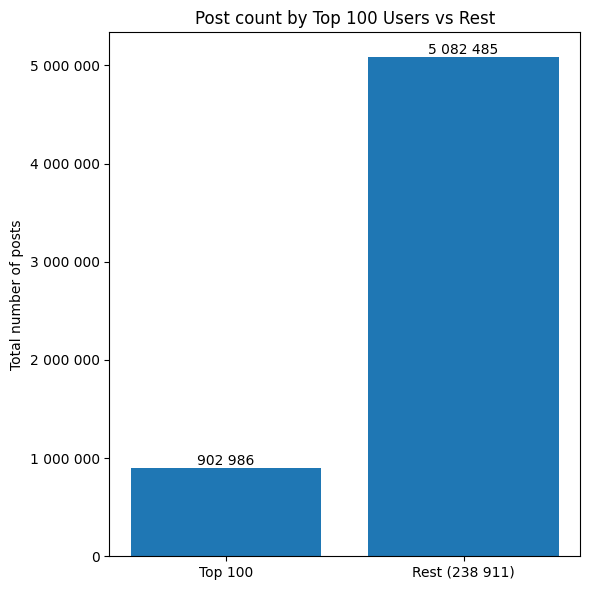

In [6]:
# Top 100 vs rest of users
top_100_sum = df.head(100)["post_count"].sum()
rest_sum = df.iloc[100:]["post_count"].sum()
rest_count = len(df) - 100

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(["Top 100", f"Rest ({rest_count:,})".replace(",", " ")], [top_100_sum, rest_sum])
ax.yaxis.set_major_formatter(space_fmt)
for i, v in enumerate([top_100_sum, rest_sum]):
    ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Total number of posts")
ax.set_title("Post count by Top 100 Users vs Rest")
plt.tight_layout()
plt.show()

# Users grouped by post count

/tmp/ipykernel_753116/4217134371.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


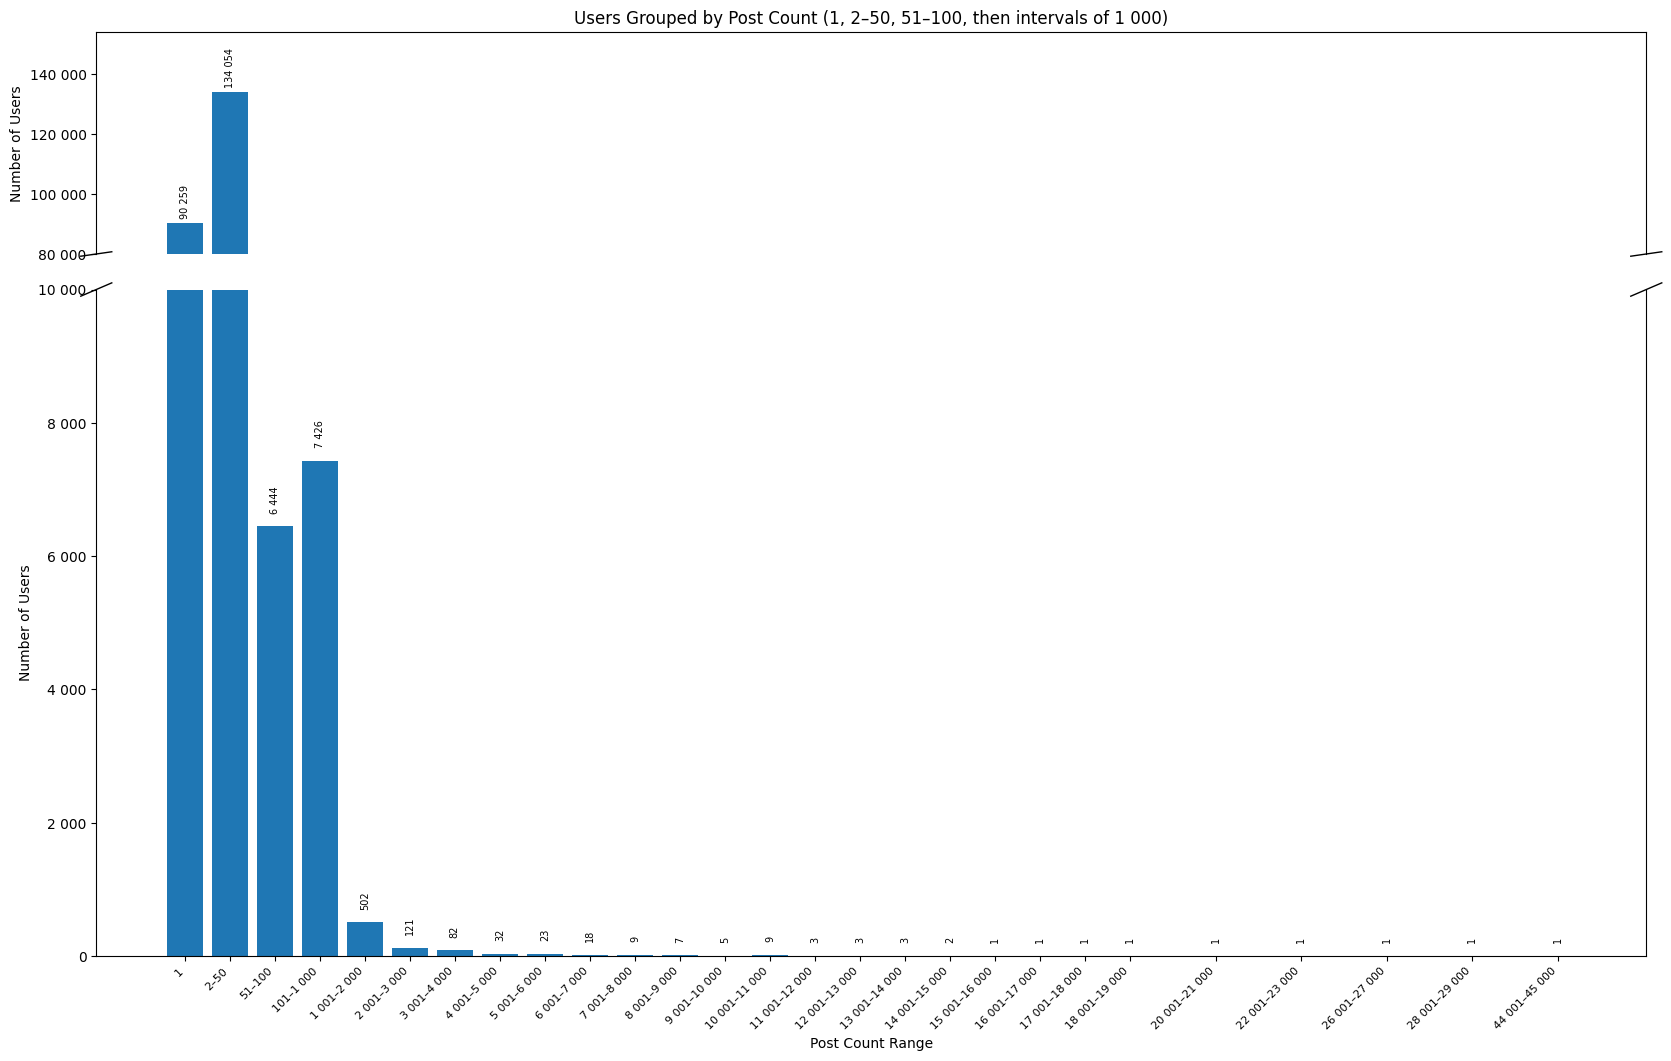

In [7]:
max_count = int(np.ceil(df["post_count"].max() / 1000) * 1000)
bins = [1, 2, 51, 101] + list(np.arange(1001, max_count + 1001, 1000))

counts, bin_edges = np.histogram(df["post_count"], bins=bins)

# Build labels
labels = []
for i in range(len(counts)):
    lo = int(bin_edges[i])
    hi = int(bin_edges[i + 1] - 1)
    if lo == hi:
        labels.append(f"{lo:,}".replace(",", " "))
    else:
        labels.append(f"{lo:,}–{hi:,}".replace(",", " "))

# Filter out empty bins
non_empty = np.where(counts > 0)[0]
labels = [labels[i] for i in non_empty]
filtered_counts = counts[non_empty]

# Build x positions with gaps where intervals are missing
gap_width = 0.9
x_positions = [0.0]
for i in range(1, len(non_empty)):
    step = 1.0
    if non_empty[i] - non_empty[i - 1] > 1:
        step += gap_width
    x_positions.append(x_positions[-1] + step)

# Broken y-axis: break between 10 000 and 80 000
break_low = 10000
break_high = 80000

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(20, 12),
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.08},
)

for ax in (ax_top, ax_bot):
    ax.bar(x_positions, filtered_counts, width=0.8)
    ax.set_xticks(x_positions)
    ax.yaxis.set_major_formatter(space_fmt)

ax_top.set_ylim(break_high, filtered_counts.max() * 1.15)
ax_bot.set_ylim(0, break_low)

# Add count labels
pad_top = (filtered_counts.max() * 1.15 - break_high) * 0.02
pad_bot = break_low * 0.02
for x, c in zip(x_positions, filtered_counts):
    if c == 0:
        continue
    label = f"{c:,}".replace(",", " ")
    if c > break_high:
        ax_top.text(
            x, c + pad_top, label, ha="center", va="bottom", fontsize=7, rotation=90
        )
    else:
        ax_bot.text(
            x, c + pad_bot, label, ha="center", va="bottom", fontsize=7, rotation=90
        )

ax_bot.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

# Hide spines between axes
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)

# Diagonal break marks
d = 0.01
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bot.set_xlabel("Post Count Range")
ax_bot.set_ylabel("Number of Users")
ax_top.set_ylabel("Number of Users")
ax_top.set_title(
    "Users Grouped by Post Count (1, 2–50, 51–100, then intervals of 1 000)"
)
plt.tight_layout()
plt.show()

# Cumulative distribution

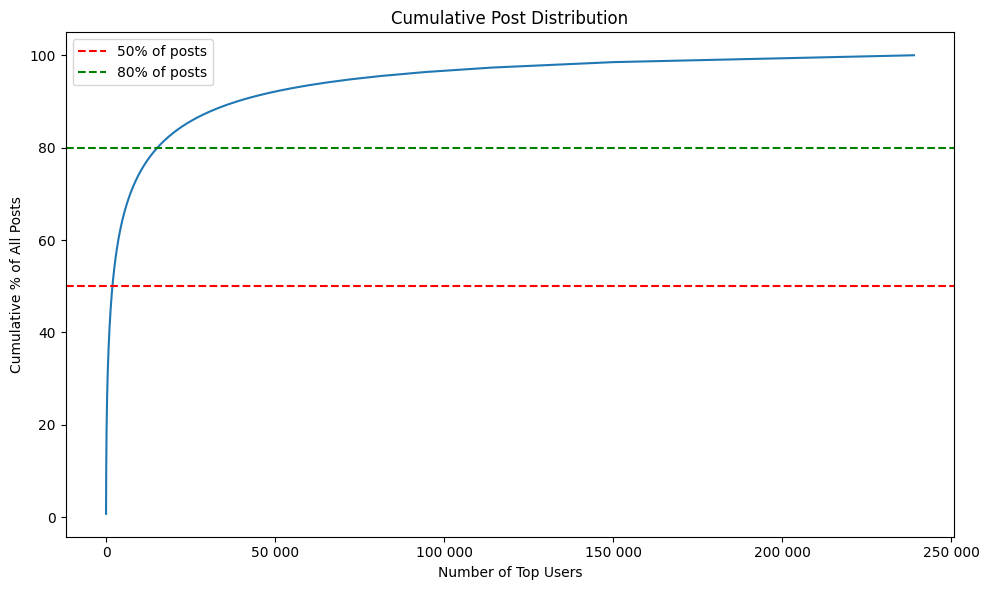

In [8]:
df_sorted = df.sort_values("post_count", ascending=False).reset_index(drop=True)
df_sorted["cumulative_posts"] = df_sorted["post_count"].cumsum()
df_sorted["cumulative_pct"] = (
    df_sorted["cumulative_posts"] / df_sorted["post_count"].sum() * 100
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(df_sorted) + 1), df_sorted["cumulative_pct"])
ax.set_xlabel("Number of Top Users")
ax.set_ylabel("Cumulative % of All Posts")
ax.set_title("Cumulative Post Distribution")
ax.xaxis.set_major_formatter(space_fmt)
ax.axhline(y=50, color="r", linestyle="--", label="50% of posts")
ax.axhline(y=80, color="g", linestyle="--", label="80% of posts")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Find how many users account for 50% and 80% of posts
total_posts = df["post_count"].sum()
users_for_50 = (df_sorted["cumulative_pct"] >= 50).idxmax() + 1
users_for_80 = (df_sorted["cumulative_pct"] >= 80).idxmax() + 1

print(
    f"Top {users_for_50:,} users ({users_for_50 / len(df) * 100:.2f}%) account for 50% of all posts"
)
print(
    f"Top {users_for_80:,} users ({users_for_80 / len(df) * 100:.2f}%) account for 80% of all posts"
)

Top 1,884 users (0.79%) account for 50% of all posts
Top 15,193 users (6.36%) account for 80% of all posts
